<a href="https://colab.research.google.com/github/MedhatElhawy/solvingNotbooks/blob/main/Solutoin_Week5_Part2_Visualization_Multicollinearity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Part 2: Data Visualization & Multicollinearity

**Instructor:** Dr. Mahmoud Eid (m.eid@fci-cu.edu.eg)
**Time:** ~1.5 hours

<div dir="rtl">
<b>النهاردة هنتعلم ازاي نستكشف الـ data ونكتشف المشاكل قبل الـ training بإذن الله!</b>
</div>

## Topics

1. Data Visualization Fundamentals
2. Correlation Analysis
3. Multicollinearity Detection (VIF)
4. One method for handling Multicollinearity

**Real Dataset:** California Housing (20,640 houses)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

plt.style.use('dark_background')
np.random.seed(42)
print("✅ Ready!")

✅ Ready!


In [22]:
# Load California Housing dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['Price'] = housing.target

print(f"Dataset: California Housing")
print(f"Samples: {len(df_housing)}")
print(f"Features: {housing.feature_names}")
print(f"\nPreview:")
print(df_housing.head())

Dataset: California Housing
Samples: 20640
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Preview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


### Exercise 1: Create Box Plots

**Task:** Create box plots for the Diabetes dataset to identify outliers.


In [23]:
# Load diabetes dataset
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data[:, :5],
                           columns=['Age', 'Sex', 'BMI', 'BP', 'S1'])

print(f"Diabetes dataset: {df_diabetes.shape}")
print(df_diabetes.head())

Diabetes dataset: (442, 5)
        Age       Sex       BMI        BP        S1
0  0.038076  0.050680  0.061696  0.021872 -0.044223
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449
2  0.085299  0.050680  0.044451 -0.005670 -0.045599
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191
4  0.005383 -0.044642 -0.036385  0.021872  0.003935


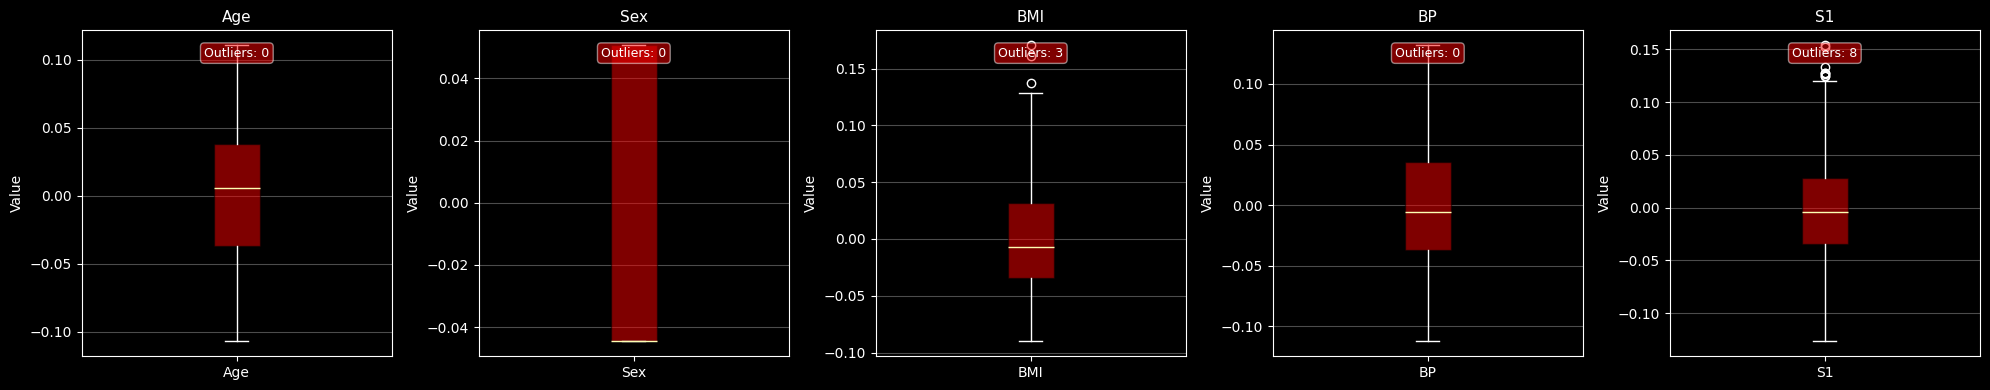

In [24]:
# YOUR TASK: Create box plots for all 5 features
fig, axes = plt.subplots(1 , 5, figsize=(20, 4))
axes = axes.flatten()

for i, col in enumerate(df_diabetes.columns):
  bp = axes[i].boxplot(df_diabetes[col], tick_labels=[col], patch_artist=True)

  for patch in bp['boxes']:
    patch.set_facecolor('red')
    patch.set_edgecolor('black')
    patch.set_alpha(0.5)
  axes[i].set_ylabel('Value', fontsize=10)
  axes[i].set_title(f'{col}', fontsize=11)
  axes[i].grid(alpha=0.3, axis='y')
  Q1 = df_diabetes[col].quantile(0.25)
  Q3 = df_diabetes[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers =((df_diabetes[col] < (Q1 - 1.5 * IQR)) | (df_diabetes[col] > (Q3 + 1.5 * IQR))).sum()
  axes[i].text(0.5, 0.95, f'Outliers: {outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
print("✅ Exercise 1 passed!")

✅ Exercise 1 passed!


### Exercise 2: Find Highly Correlated Features

**Task:** Identify all feature pairs with |correlation| > 0.7


In [33]:
# YOUR TASK: Find highly correlated pairs
# YOUR CODE HERE
corr_matrix = df_housing.corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
  for j in range(i+1, len(corr_matrix.columns)):
    if abs(corr_matrix.iloc[i, j]) > 0.7:
      high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))

print(f"\nFound {len(high_corr_pairs)} highly correlated pairs")


Found 2 highly correlated pairs


In [34]:
print("✅ Exercise 2 passed!")

✅ Exercise 2 passed!


### Exercise 3: Compute VIF

**Task:** Compute VIF for the Diabetes dataset features.


In [35]:
# Load diabetes data
diabetes = load_diabetes()
X_diabetes = diabetes.data[:, :5]  # Use first 5 features
feature_names_diabetes = ['Age', 'Sex', 'BMI', 'BP', 'S1']

print(f"Diabetes features: {feature_names_diabetes}")

Diabetes features: ['Age', 'Sex', 'BMI', 'BP', 'S1']


In [36]:
# YOUR TASK: Compute VIF for diabetes features
# YOUR CODE HERE
# Compute VIF for each feature
def compute_vif(X):
    """Compute VIF for each feature"""
    vif_data = []
    for i in range(X.shape[1]):
        # Use all other features to predict feature i
        X_i = X[:, i]
        X_others = np.delete(X, i, axis=1)

        # Fit linear regression
        lr = LinearRegression()
        lr.fit(X_others, X_i)

        # Compute R²
        r_squared = lr.score(X_others, X_i)

        # VIF = 1 / (1 - R²)
        vif = 1 / (1 - r_squared) if r_squared < 0.999 else np.inf
        vif_data.append(vif)

    return np.array(vif_data)


X_diabetes = diabetes.data
vif_values = compute_vif(X_diabetes)

print("Feature                VIF")
print("-" * 35)
for name, vif in zip(housing.feature_names, vif_values):
    print(f"{name:15s} {vif:10.2f}")

Feature                VIF
-----------------------------------
MedInc                1.22
HouseAge              1.28
AveRooms              1.51
AveBedrms             1.46
Population           59.20
AveOccup             39.19
Latitude             15.40
Longitude             8.89


In [37]:
print("✅ Exercise 3 passed!")

✅ Exercise 3 passed!
